In [ ]:
# Stock Price Prediction using LSTM, RNN, and GRU

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, GRU, Dropout

In [ ]:
#Load Dataset
url = "https://itv-contentbucket.s3.ap-south-1.amazonaws.com/Exams/AI/Stock+Price+Prediction+using+Sequence+Model/FINAL_FROM_DF.csv"
df = pd.read_csv(url)

df.head()

,SYMBOL,SERIES,OPEN,HIGH,LOW,CLOSE,LAST,PREVCLOSE,TOTTRDQTY,TOTTRDVAL,TIMESTAMP,TOTALTRADES,ISIN
0,20MICRONS,EQ,37.80,37.80,36.15,36.85,37.40,37.05,27130,994657.90,2017-06-28,202,INE144J01027
1,3IINFOTECH,EQ,4.10,4.85,4.00,4.55,4.65,4.05,20157058,92148517.65,2017-06-28,7353,INE748C01020
2,3MINDIA,EQ,13425.15,13469.55,12920.00,13266.70,13300.00,13460.55,2290,30304923.35,2017-06-28,748,INE470A01017
3,63MOONS,EQ,61.00,61.90,60.35,61.00,61.10,60.65,27701,1689421.00,2017-06-28,437,INE111B01023
4,8KMILES,EQ,546.10,548.00,535.00,537.45,535.20,547.45,79722,43208620.05,2017-06-28,1866,INE650K01021


In [ ]:
#Data Preprocessing
#Select required columns
df = df[['OPEN', 'CLOSE']]
df.dropna(inplace=True)

In [ ]:
#Data Preprocessing
#Normalize data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [ ]:
#Create Time Series Sequences
def create_sequences(data, time_step=50):
    X, y = [], []

    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i])
        y.append(data[i])

    return np.array(X), np.array(y)

time_step = 50
X, y = create_sequences(scaled_data, time_step)

In [ ]:
#Train-Test Split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
#LSTM Model (Open Price)
#Target selection
y_train_open = y_train[:, 0]
y_test_open = y_test[:, 0]

In [ ]:
#LSTM Model (Open Price)
#Model
model_lstm = Sequential()

model_lstm.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Train
model_lstm.fit(X_train, y_train_open, epochs=20, batch_size=32)

Epoch 1/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1059s 50ms/step - loss: 2.9805e-04
Epoch 2/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1114s 50ms/step - loss: 2.9276e-04
Epoch 3/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1057s 50ms/step - loss: 2.9074e-04
Epoch 4/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1123s 51ms/step - loss: 2.8910e-04
Epoch 5/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1074s 51ms/step - loss: 2.8704e-04
Epoch 6/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1083s 50ms/step - loss: 2.8244e-04
Epoch 7/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1049s 50ms/step - loss: 2.5561e-04
Epoch 8/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1103s 50ms/step - loss: 2.3089e-04
Epoch 9/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1050s 50ms/step - loss: 2.1182e-04
Epoch 10/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1105s 50ms/step - loss: 2.0585e-04
Epoch 11/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1045s 49ms/step - loss: 1.9543e-04
Epoch 12/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1105s 50ms/step - loss: 2.3109e-04
Epoch 13/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1044

In [ ]:
#RNN Model (Close Price Prediction)
#Target selection
y_train_close = y_train[:, 1]
y_test_close = y_test[:, 1]

In [ ]:
#Model
model_rnn = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

In [ ]:
#Train
model_rnn.fit(X_train, y_train_close, epochs=20, batch_size=32)

Epoch 1/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 519s 24ms/step - loss: 3.3585e-04
Epoch 2/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 509s 24ms/step - loss: 2.9812e-04
Epoch 3/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 564s 24ms/step - loss: 2.9662e-04
Epoch 4/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 562s 24ms/step - loss: 2.9630e-04
Epoch 5/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 510s 24ms/step - loss: 2.9618e-04
Epoch 6/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 506s 24ms/step - loss: 2.9630e-04
Epoch 7/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 502s 24ms/step - loss: 2.9615e-04
Epoch 8/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 507s 24ms/step - loss: 2.9605e-04
Epoch 9/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 573s 27ms/step - loss: 2.9609e-04
Epoch 10/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 650s 28ms/step - loss: 2.9610e-04
Epoch 11/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 596s 28ms/step - loss: 2.9610e-04
Epoch 12/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 590s 28ms/step - loss: 2.9613e-04
Epoch 13/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 555s 26ms/step -

In [ ]:
#GRU Model (Reference Model)
model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')

In [ ]:
#Train
model_gru.fit(X_train, y_train_close, epochs=20, batch_size=32)

Epoch 1/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1352s 64ms/step - loss: 2.1388e-04
Epoch 2/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1357s 64ms/step - loss: 1.9913e-04
Epoch 3/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1389s 64ms/step - loss: 1.8598e-04
Epoch 4/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1346s 64ms/step - loss: 1.7346e-04
Epoch 5/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1405s 64ms/step - loss: 1.6409e-04
Epoch 6/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1354s 64ms/step - loss: 1.4977e-04
Epoch 7/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1360s 64ms/step - loss: 1.4903e-04
Epoch 8/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1346s 64ms/step - loss: 1.3742e-04
Epoch 9/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1379s 65ms/step - loss: 1.3638e-04
Epoch 10/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1385s 64ms/step - loss: 1.3628e-04
Epoch 11/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1392s 64ms/step - loss: 1.4004e-04
Epoch 12/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1351s 64ms/step - loss: 1.2430e-04
Epoch 13/20
21159/21159 ━━━━━━━━━━━━━━━━━━━━ 1417

In [ ]:
#Predictions
pred_lstm = model_lstm.predict(X_test)
pred_rnn = model_rnn.predict(X_test)
pred_gru = model_gru.predict(X_test)

5290/5290 ━━━━━━━━━━━━━━━━━━━━ 84s 16ms/step
5290/5290 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step
5290/5290 ━━━━━━━━━━━━━━━━━━━━ 75s 14ms/step


In [ ]:
#Evaluation
from sklearn.metrics import mean_squared_error

print("LSTM MSE (Open):", mean_squared_error(y_test_open, pred_lstm))
print("RNN MSE (Close):", mean_squared_error(y_test_close, pred_rnn))
print("GRU MSE (Close):", mean_squared_error(y_test_close, pred_gru))

LSTM MSE (Open): 0.00022371836828846667
RNN MSE (Close): 0.014749497286914812
GRU MSE (Close): 0.00020307727910834036


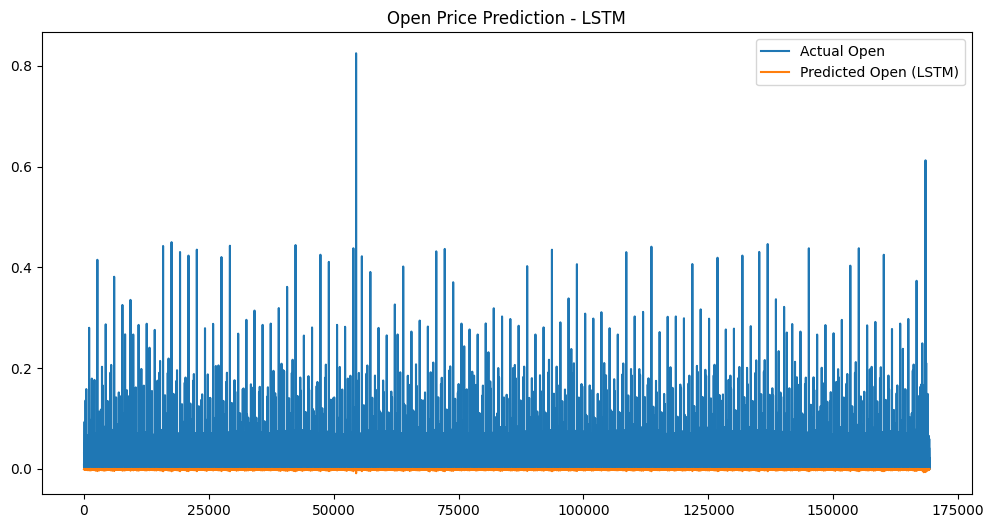

In [ ]:
#Visualization
plt.figure(figsize=(12,6))

plt.plot(y_test_open, label='Actual Open')
plt.plot(pred_lstm, label='Predicted Open (LSTM)')

plt.legend()
plt.title("Open Price Prediction - LSTM")
plt.show()